# Objectif 

L'objectif de ce notebook est de définir le guide d'onde de Pekeris étudié dans ce dossier. L'objectif de ce guide d'onde est de fournir un cas test simple pour l'évaluation de différentes propriétés relatives au vecteur de RTF :

* Performances des estimateurs 
* Performances de la méthodes MFP - RTF 

L'environnement considéré est un guide d'onde de Pekeris dont les paramètres sont les suivants : 

* Dans la colonne d'eau :
    * $c_0 = 1500 m/s$
    * $\rho_0 = 1000 kg/m^3$
* Dans le sédiment : 
    * $c_1 = 1600 m/s$
    * $\rho_1 = 1500 kg/m^3$
    * $\alpha_1 = 0.2 dB/\lambda$

Ce guide d'onde est identique à celui utiliser pour illustrer les propriétés de bases de la théorie des modes normaux (Cf notebook basic_modal_features.ipynb) 


In [4]:
import os
import sys
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt

sys.path.append(r"C:\Users\baptiste.menetrier\Desktop\devPy\phd")

# Load usefull functions
import source.global_constants as g
from publication.publication_figure import PubFigure, LargeFigure, SmallFigure
from propa.ideal_waveguide import (
    psi,
    psi_normalised,
    h,
    field,
    plot_tl,
    nb_propagating_modes,
    print_arrivals,
)

from propa.kraken_toolbox.src.kraken_testcase import (
    KrakenTestCase,
    DomainProperties,
    SourceProperties,
    ReceiverProperties,
    KrakenProperties,
)
from propa.kraken_toolbox.src.kraken_env import (
    KrakenTopHalfspace,
    KrakenMedium,
    KrakenBottomHalfspace,
    KrakenAttenuation,
    KrakenField,
    Bathymetry,
)
from propa.kraken_toolbox.src.kraken_manager import KrakenManager
from propa.kraken_toolbox.plot_utils import plotshd, plotmode
from propa.kraken_toolbox.utils import default_nb_rcv_z
from signals.AcousticComponent import AcousticSource
from source.signal_generator import SignalGenerator
from source.ssp_profiles import SSPProfile
from misc import mult_along_axis

pfig = PubFigure()


In [5]:
folder_root = r"C:\Users\baptiste.menetrier\Desktop\devPy\phd\propa\rtf\rtf_estimation\pekeris_short_ir_waveguide"
tc_root_dir = (
    r"C:\Users\baptiste.menetrier\Desktop\devPy\phd\propa\kraken_toolbox\testcases"
)
img_folder_path = os.path.join(folder_root, "img")
data_folder_path = os.path.join(folder_root, "data")

# Dataset path
tf_demo_fpath = os.path.join(data_folder_path, "tf_demo.nc")
tf_perf_fpath = os.path.join(data_folder_path, "tf_perf.nc")

sig_fpath = os.path.join(data_folder_path, "received_signals.nc")

# Etape 1 : calcul des fonctions de transfert dans le guide d'onde de Pekeris 

## Paramètres du guide d'onde de Pekeris

In [6]:
# Waveguide geometry
depth = 1000.0  # m
max_range_km = 50  # km

# Water
c_water = g.c0
rho_water = g.rho_w  # kg/m^3

# # Sediment
# c_sediment = 1550.0  # m/s
# rho_sediment = 1500.0  # kg/m^3
# alpha_sediment = 0.2  # dB/lambda

# Sediment (Pekeris pulse)
c_sediment = 1600.0  # m/s
rho_sediment = 1500.0  # kg/m^3
alpha_sediment = 0.2  # dB/lambda


## Paramètres de la source 

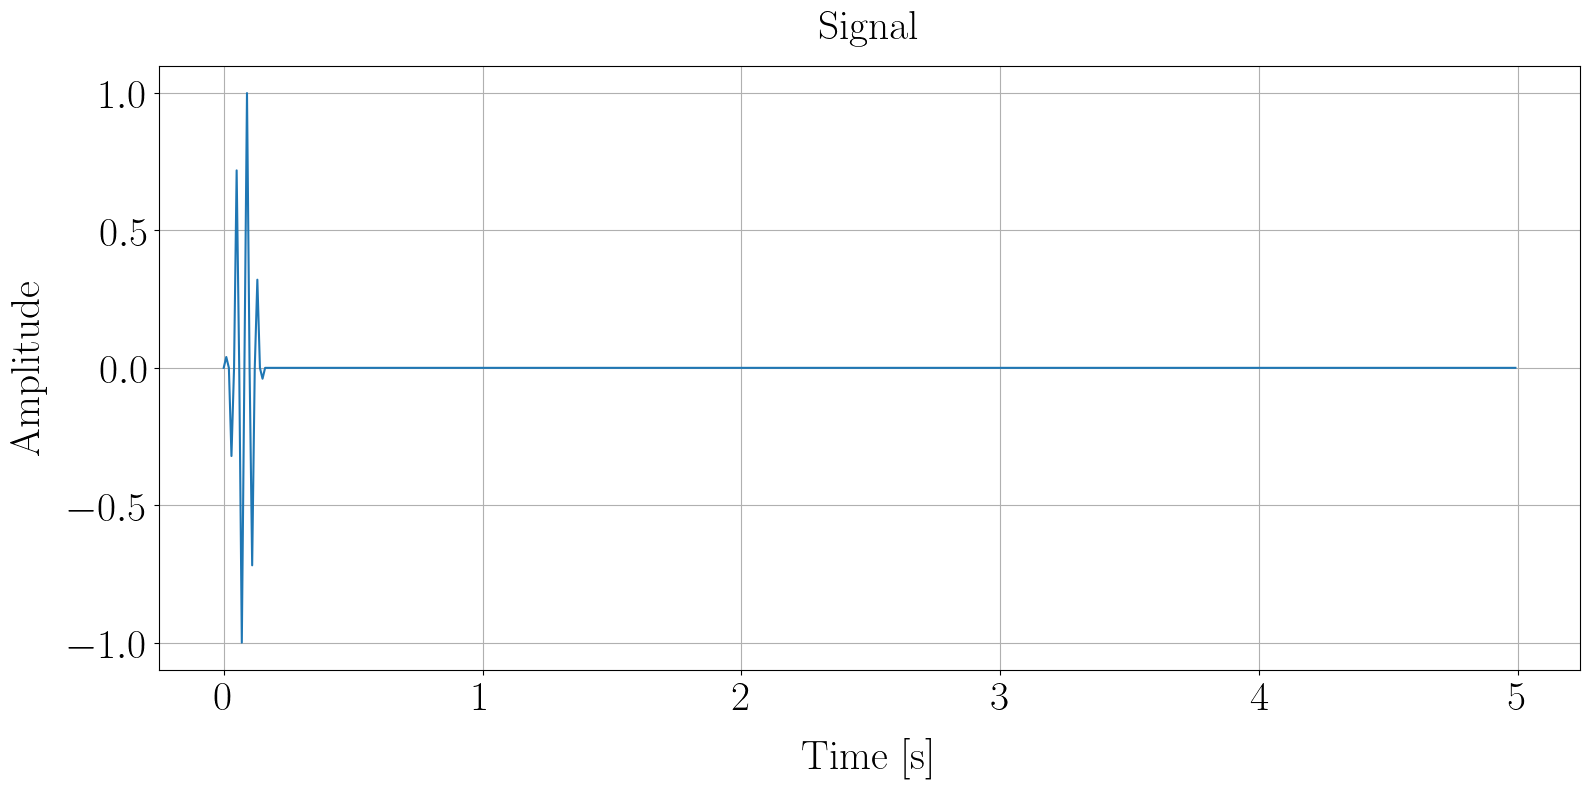

In [7]:
src_depth = 5 # m
src_min_freq = 0 # Hz
src_max_freq = 50 # Hz
src_fs = 100  # Hz
src_signal_duration = 5  # s

# Create dummy signal to make it easy to run kraken simulation
fc = 25
sg = SignalGenerator()
s, t = sg.pulse(T=src_signal_duration, fc=fc, fs=src_fs, t0=0)

# # Shaded sinusoidal signal = sinusoidal x hanning window 
# win_size = s.size // 3
# window = np.ones(win_size)
# # window = np.hanning(win_size)

# window = np.pad(
#     window,
#     (0, s.size - win_size),
#     "constant",
#     constant_values=0,
# )

# s = np.sin(2 * np.pi * fc * t) * window  # Sinusoidal pulse

s = sg.normalize_sig(s, normalize="max")
# Plot time serie
sg.plot_signal(t, s)

src = AcousticSource(
    signal=s,
    time=t,
    name="Pulse",
    waveguide_depth=depth,
    window=None,
    nfft=2 ** int(np.log2(s.size) + 1),
)

## Définition du cas test avant calcul Kraken

In [5]:
name = "perekis_short_ir_waveguide"
title = "Pekeris waveguide with short impulse response"

# Common properties
zmin = 0
zmax = depth
rmax = max_range_km * 1e3

min_phase_speed = 1000
max_phase_speed = 20000

bott_props = {
    "rho": rho_sediment * 1e-3,  # Density (g/cm^3)
    "c_p": c_sediment,  # P-wave celerity (m/s)
    "c_s": 0.0,  # S-wave celerity (m/s)
    "a_p": alpha_sediment,  # Compression wave attenuation (dB/wavelength)
    "a_s": 0.0,  # Shear wave attenuation (dB/wavelength)
}

# Set domain properties
domain_properties = DomainProperties(zmin=zmin, zmax=zmax, rmin=0, rmax=rmax, unit="m")

# Set source properties
src_properties = SourceProperties(
    src_type="point_source", src_depth=src_depth, freq=src.kraken_freq
)
# Set receiver properties : needs to cover the whole water domain
rcv_z_min = zmin
rcv_z_max = depth

# Number of receiver depths / ranges (flp file) : sufficient resolution for later use (can be easily downsampled afterwards)
dr = 50
dz = 5
nr_flp = int(rmax / dr) + 1
nz_flp = int(rcv_z_max / dz) + 1

rcv_properties = ReceiverProperties(
    zmin=rcv_z_min, zmax=rcv_z_max, rmin=0, rmax=rmax, unit="m"
)

# Set kraken properties
nmedia = 2

top_hs = KrakenTopHalfspace(
    boundary_condition="vacuum",
    halfspace_properties=None,
    twersky_scatter_properties=None,
)

bott_hs = KrakenBottomHalfspace(
    boundary_condition="acousto_elastic",
    sigma=0.0,
    halfspace_properties=bott_props,
    fmin=src.kraken_freq.min(),
    alpha_wavelength=10,
)
# Set attenuation properties
att = KrakenAttenuation(units="dB_per_wavelength", use_volume_attenuation=False)
# Set SSP profile
z = [0, zmax]
c = [c_water, c_water]  # Constant celerity profile
ssp = SSPProfile(z=z, c=c)

# Create the medium = water column layer
medium = KrakenMedium(
    ssp_interpolation_method="C_linear",
    z_ssp=ssp.z,
    c_p=ssp.c,
    c_s=0.0,
    rho=1.0,
    a_p=0.0,
    a_s=0.0,
    nmesh=0,
    sigma=0.0,
)

bott_hs.derive_sedim_layer_max_depth(domain_properties.zmax_m)
max_rcv_depth = bott_hs.sedim_layer_max_depth
n_rcv_z = default_nb_rcv_z(
    fmax=src.kraken_freq.max(), max_depth=max_rcv_depth, n_per_l=10
)
field = KrakenField(
    phase_speed_limits=[min_phase_speed, max_phase_speed],
    src_depth=[src_properties.depth],
    n_rcv_z=n_rcv_z,
    rcv_z_min=0,
    rcv_z_max=max_rcv_depth,
    rcv_r_max=0.0,
)

kraken_properties = KrakenProperties(
    mode_coupling="coupled",
    mode_addition="coherent",
    n_mode=100,
    nr=nr_flp,
    nz=nz_flp,
    nmedia=nmedia,
    top_hs=top_hs,
    bott_hs=bott_hs,
    att=att,
    medium=medium,
    field=field,
)


k_tc = KrakenTestCase(
    name=name,
    title=title,
    root_dir=tc_root_dir,
    domain_properties=domain_properties,
    src_properties=src_properties,
    rcv_properties=rcv_properties,
    kraken_properties=kraken_properties,
)

In [6]:
# Kraken compute otpion
run_kraken = False
# run_kraken = True

## Calcul des fonctions de Green du guide d'onde étudié

In [7]:
if run_kraken:
    km = KrakenManager()
    pressure_field, field_pos = km.runkraken(
        env=k_tc.env, flp=k_tc.flp, frequencies=k_tc.src.freq
    )

## Sauvergarde des fonctions de transfert du guide d'onde 

In [8]:
if run_kraken:
    # Store pressure field as netcdf using xarray
    pressure_field = np.squeeze(pressure_field)  # Remove singleton dimensions if any
    ds_tf = xr.Dataset(
        data_vars=dict(
            tf_real=(["f", "z", "r"], np.real(pressure_field)),
            tf_imag=(["f", "z", "r"], np.imag(pressure_field)),
        ),
        coords=dict(
            f=k_tc.src.freq,
            z=field_pos["r"]["z"],
            r=field_pos["r"]["r"],
        ),
        attrs=dict(
            title="Transfer functions for Pekeris waveguide",
            description="Transfer functions computed using Kraken for a Pekeris waveguide with short impulse response.",
            # date_created=np.datetime64("now"),
            note="Dataset for demo purpose: high spatial resolution and full range coverage.",
            type="demo",
            fs=src_fs,
            signal_duration=src_signal_duration,

        ),
    )
    # Save to netcdf
    ds_tf.to_netcdf(tf_demo_fpath)
else:
    # Load transfer functions from netcdf
    ds_tf = xr.open_dataset(tf_demo_fpath)

## Visualisation des modes du guide d'onde 

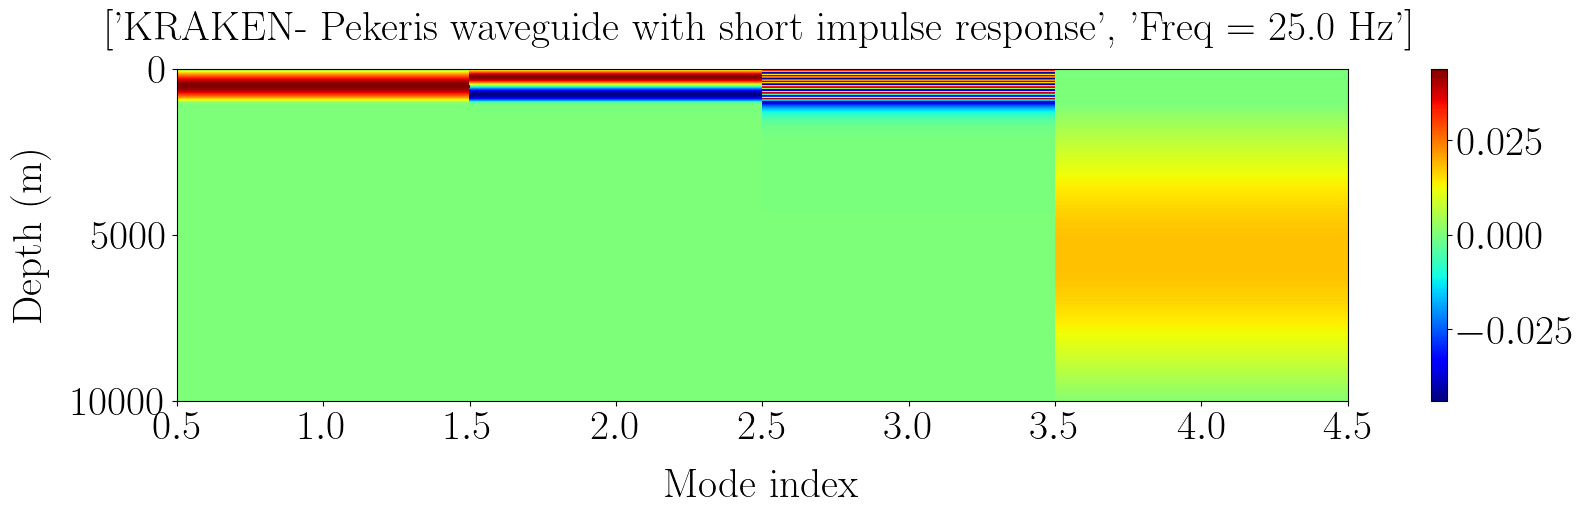

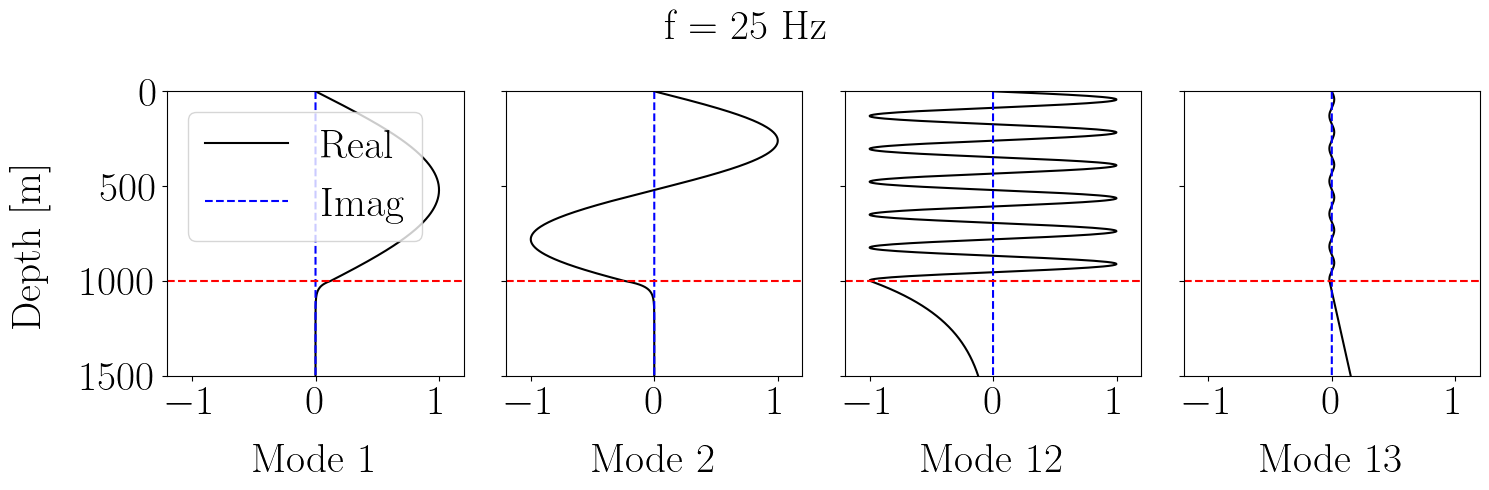

In [9]:
lfig = LargeFigure()

f_visu = 25  # Frequency to visualize
mode_fpath = os.path.join(k_tc.io_files_dir, k_tc.env.filename)
plotmode(
    mode_fpath,
    freq=[f_visu],
    modes=[1, 2, 12, 13],
    bathy_depth=k_tc.bathy.bathy_depth[0],
    normalize_mode=True,
)

fig = plt.gcf()
plt.ylim([depth+500, 0])
fig.suptitle(f"f = {f_visu} Hz")

# Save figure as pdf
fpath = os.path.join(img_folder_path, f"{name}_4modes.pdf")
plt.savefig(fpath, dpi=300)

In [10]:
# fréquence de coupure du mode m
m = 13
f_0m = ((m -0.5) * c_water) / (2 * depth * np.sqrt(1 - (c_water / c_sediment) ** 2))
print(f"Cut-off frequency of mode {m} : {f_0m:.2f} Hz")

Cut-off frequency of mode 13 : 26.94 Hz


## Visualisation des pertes à 3 fréquences 

Remarque : ici la source est placée à  1 m au dessus de la surface pour le calcul Kraken, l'objectif est d'exploiter la réciprocité pour considérée le signal reçu sur une antenne linéaire horizontal située 1 au dessus du fond.  

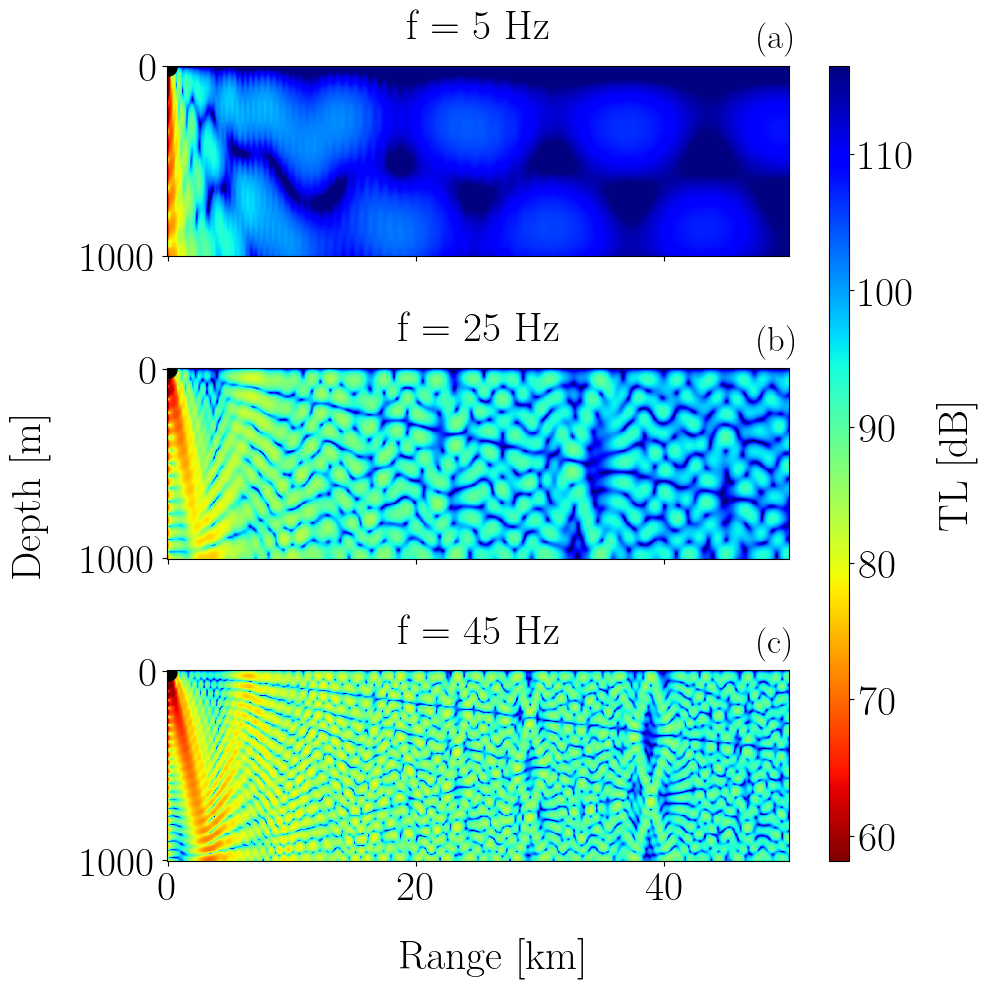

In [11]:
lfig = LargeFigure(size=(16, 7.5))

# Plot tl at a single frequency
tf = ds_tf.tf_real + 1j * ds_tf.tf_imag  # (nf, nz, nr)
freq_plot = [5, 25, 45]
p_field = tf.sel(f=freq_plot, method="nearest").values
p_field[(p_field == 0) | np.isnan(p_field)] = 1e-20
tl = -20 * np.log10(np.abs(p_field))
tlmax = np.percentile(tl, 95)
tlmin = np.percentile(tl, 1) - 15

# Plot TL for each number of modes
fig, axs = plt.subplots(len(freq_plot), figsize=(10, 10), sharex=True)
abcd_labels = ["a", "b", "c"]
for i, fp in enumerate(freq_plot):
    p_field = p_field[i, ...]
    title = f"f = {fp} Hz"

    # Plot TL
    im = axs[i].pcolormesh(
        tf.r * 1e-3, tf.z, tl[i], cmap="jet_r", vmin=tlmin, vmax=tlmax, rasterized=True
    )

    # Add source position
    if src_depth is not None:
        axs[i].scatter(
            0,
            src_depth,
            color="k",
            marker="o",
            s=150,
        )
    axs[i].set_title(title)
    axs[i].invert_yaxis()

    # Add a, b, c labels
    axs[i].text(
        0.95,
        1.05,
        f"({abcd_labels[i]})",
        transform=axs[i].transAxes,
        fontsize=25,
        fontweight="bold",
        va="bottom",
    )

fig.supxlabel("Range [km]")
fig.supylabel("Depth [m]")

# Add common colorbar
cbar = fig.colorbar(im, ax=axs, orientation="vertical", pad=0.05, aspect=40)
cbar.set_label("TL [dB]")

# Save figure as pdf
fpath = os.path.join(img_folder_path, f"{name}_tl_3freqs.pdf")
plt.savefig(fpath)

## Visualisation du signal propagé

In [12]:
rmin_visu = 30 * 1e3  # Minimum range for visualization
rmax_visu = 30 * 1e3  # Maximum range for visualization
ds_tf_pulse = ds_tf.sel(r=slice(rmin_visu, rmax_visu))  # Select receivers at 30 km range
rcv_range = ds_tf_pulse.r.values

delays = rcv_range / g.c0
rcv_depth = np.linspace(k_tc.flp.rcv_z_min, k_tc.flp.rcv_z_max, k_tc.flp.n_rcv_z)

In [13]:
# Source spectrum
Sf = src.positive_spectrum
fmin = np.min(ds_tf_pulse.f.values)
idx_first_freq = np.argmin(np.abs(src.positive_freq - fmin))
Sf = Sf[idx_first_freq:]

# Derive delay for each receiver
tau_rcv = ds_tf_pulse.r.min().values / g.c0
# tau_rcv = target_range / g.c0

tf = ds_tf_pulse.tf_real + 1j * ds_tf_pulse.tf_imag  # (nf, nz, nr)

# Derive received spectrum (Y = SH)
k0 = 2 * np.pi * ds_tf_pulse.f.values / g.c0
norm_factor = np.exp(1j * k0) / (4 * np.pi)

# # Derive delay factor to take into account the propagation time
delay_rcv = np.exp(1j * 2 * np.pi * tau_rcv * ds_tf_pulse.f.values)  # (nf,)

y_f = mult_along_axis(tf, Sf * norm_factor * delay_rcv, axis=0)

nfft_inv = (
    4 * src.nfft
)  # according to Jensen et al. (2000) p.616 : dt < 1 / (8 * fmax) for visual inspection of the propagated pulse
T_tot = 1 / src.df
dt = T_tot / nfft_inv
time_vector = np.arange(0, T_tot, dt)

# FFT inv to get signal
y_t = np.fft.irfft(y_f, axis=0, n=nfft_inv)  # (nt, nz, nr)
y_t = np.real(y_t)  # Keep only real part

# Build dataset to save
ds_sig = xr.Dataset(
    coords=dict(
        t=time_vector,
        z=ds_tf_pulse.z,
        r=ds_tf_pulse.r,
    ),
    data_vars=dict(
        s=(["t", "z", "r"], y_t),
    ),
)

# Save dataset
ds_sig.to_netcdf(sig_fpath)

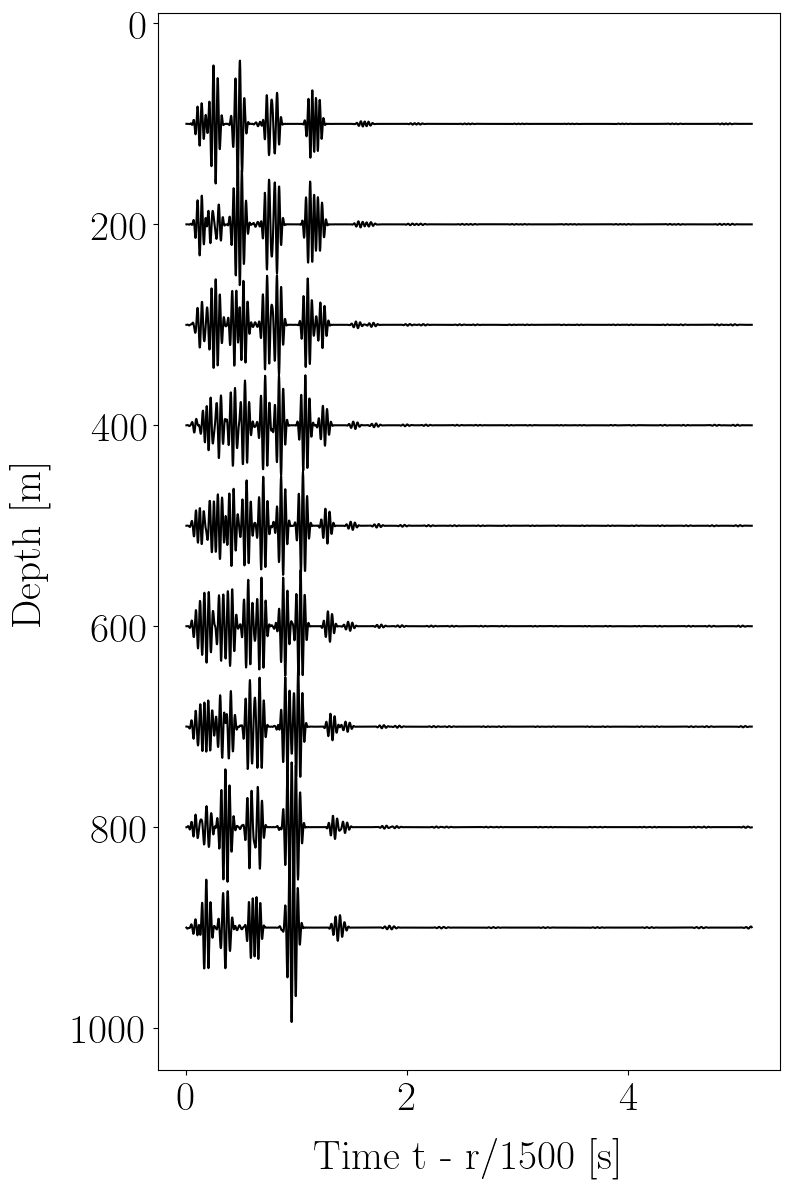

In [14]:
range_plot = np.array([30000])
dz = 100
depth_plot = np.arange(dz, 1000, dz)  # Depths to plot

# Scale for visualization
max_amplitude = ds_sig.s.max().values
alpha_dilatation = 1 * dz 
ds_sig["s"] = ds_sig.s / max_amplitude * alpha_dilatation

# Roll over time axis to start at zero
tau_roll = (
    range_plot[0] - ds_sig.r.min().values
) / g.c0  # Roll time axis to start at zero
ts = ds_sig.t.diff("t").values[0]
idx_tau_roll = int(tau_roll / ts)
sig_roll = ds_sig.s.roll(t=-idx_tau_roll, roll_coords=False)

z_offset = depth_plot[1] - depth_plot[0]
for ir, r in enumerate(range_plot):
    plt.figure(figsize=(8, 12))
    for iz, z in enumerate(depth_plot):
        sig = sig_roll.sel(z=z, r=r, method="nearest") + (iz + 1) * z_offset
        if z == src_depth:
            sig.plot(color="r", label="Source depth")
        else:
            sig.plot(color="k")

    # Revert y-axis
    ax = plt.gca()
    ax.invert_yaxis()
    # plt.xlim([0, 1])
    plt.xlabel(f"Time  t - r/{g.c0} [s]")
    plt.ylabel("Depth [m]")
    plt.title(
        "",
    )
    # Save figure as pdf
    fpath = os.path.join(img_folder_path, f"{name}_received_signals_{range_plot[0]}m.pdf")
    plt.savefig(fpath)

Text(0, 0.5, 'Amplitude')

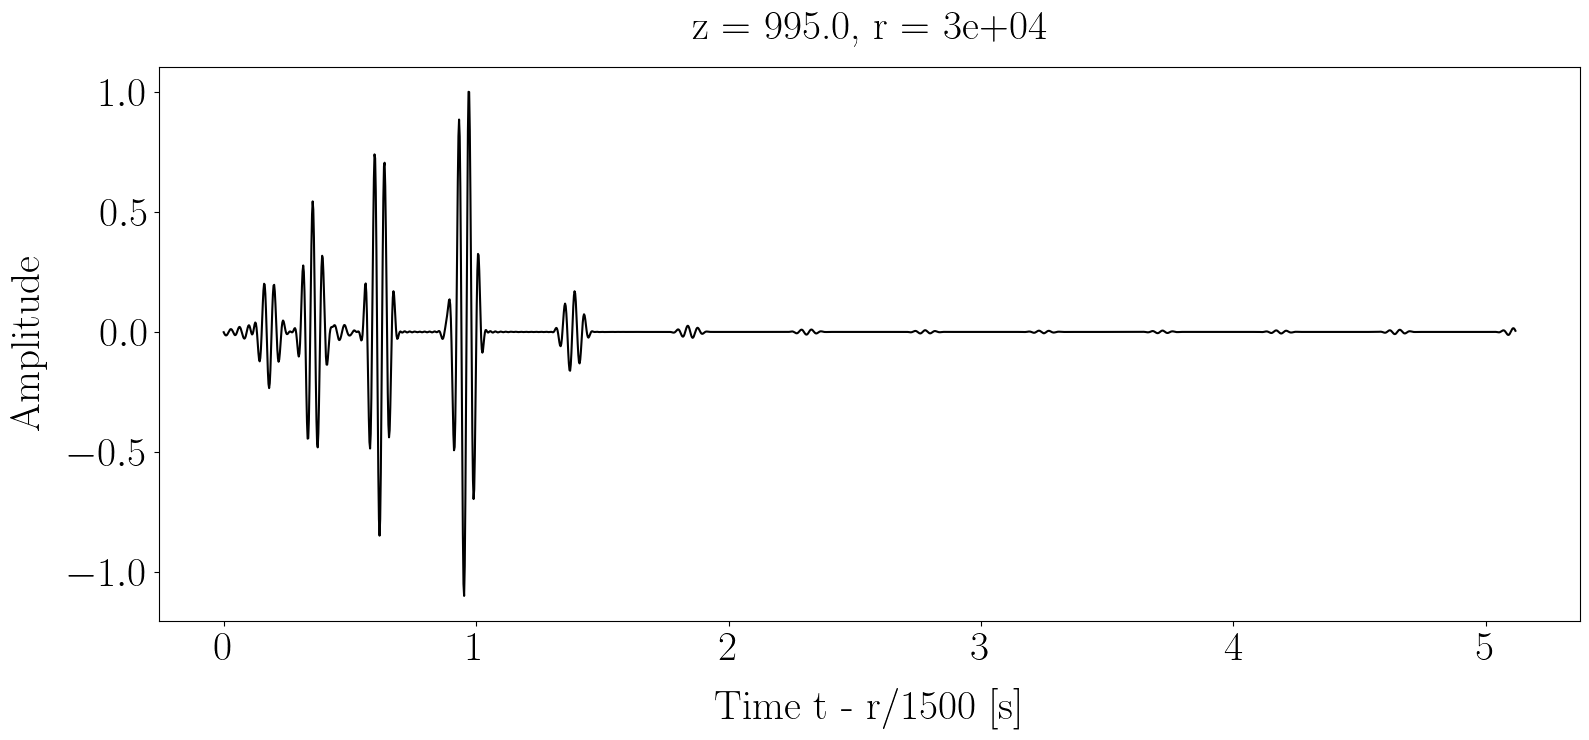

In [15]:
z_plot = 995
r_plot = 30 * 1e3

ts = ds_sig.t.diff("t").values[0]
tau_roll = (r_plot - ds_sig.r.min().values) / g.c0  # Roll time axis to start at zero
idx_tau_roll = tau_roll / ts
idx_tau_roll = idx_tau_roll.astype(int)

sig = ds_sig.s.sel(r=r_plot, z=z_plot, method="nearest")
sig = sig / sig.max().values
sig_roll = sig.roll(t=-idx_tau_roll, roll_coords=False)
sig_roll.plot(color="k")
plt.xlabel(f"Time  t - r/{g.c0} [s]")
plt.ylabel("Amplitude")

Window duration for RMS: 0.25 s


Text(0.5, 1.0, '')

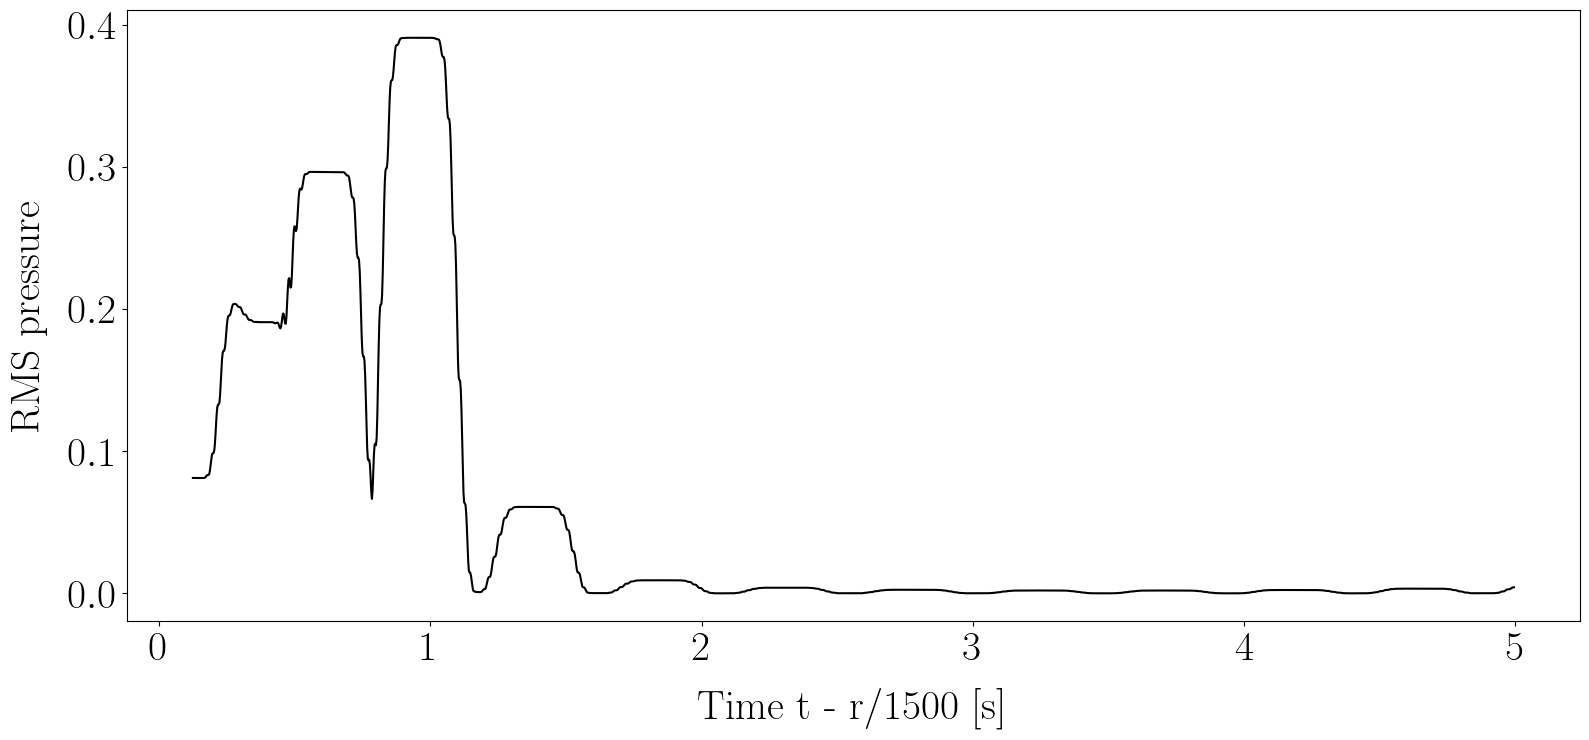

In [16]:
# Derive prms
p = sig_roll
t_win = 100
# print(f"Window size for RMS: {t_win} samples")
print(f"Window duration for RMS: {t_win * ts:.2f} s")
p2_roll = (p**2).rolling(t=t_win, center=True).mean()  
p_rms = np.sqrt(p2_roll)

# Plot p_rms
plt.figure()
p_rms.plot(color="k")
plt.xlabel(f"Time  t - r/{g.c0} [s]")
plt.ylabel("RMS pressure")
plt.title("")
# plt.xlim([0, 4])  # Cropp the end to avoid wrapped around signal artefacts

Text(0.5, 1.0, '')

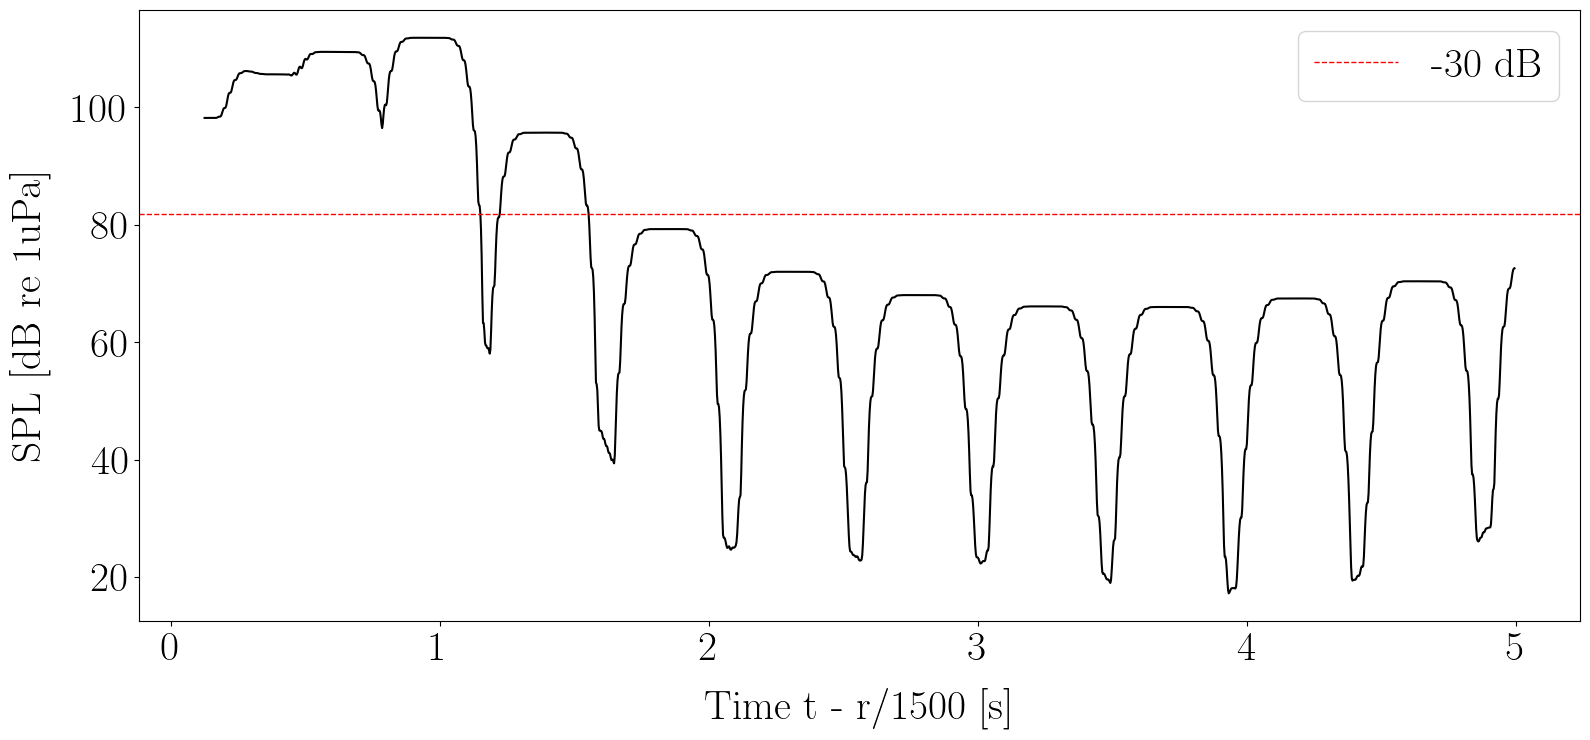

In [17]:
# Derive SPL
# p_rms /= p_rms.max().values
spl = 20 * np.log10(p_rms / g.p0)

# Plot spl
spl.plot(color="k")

# Add threshold line
threshold = -30  # Threshold in dB
th = np.max(spl).values + threshold
plt.axhline(
    y=th,
    color="r",
    linestyle="--",
    linewidth=1,
    label=f"{threshold} dB",
)

# plt.xlim([0, 4])  # Cropp the end to avoid wrapped around signal artefacts
plt.xlabel(f"Time  t - r/{g.c0} [s]")
plt.ylabel("SPL [dB re 1uPa]")
plt.legend()
plt.title("")

# # Save figure as pdf
# fpath = os.path.join(img_folder_path, f"{name}_ir_spl_{r_plot}m.pdf")
# plt.savefig(fpath)

# Visualisation de la réponse impulsionnelle

In [18]:
rmin_visu = 20 * 1e3  # Minimum range for visualization
rmax_visu = 40 * 1e3  # Maximum range for visualization
dr_visu = 5000  # Range step for impulse response visualization
r_visu_ir = np.arange(
    rmin_visu, rmax_visu, dr_visu
)  # Range for impulse response visualization
ds_tf_ir = ds_tf.sel(r=r_visu_ir, method="nearest")  # Select receivers at 30 km range
rcv_range = ds_tf_ir.r.values

delays = rcv_range / g.c0
rcv_depth = np.linspace(k_tc.flp.rcv_z_min, k_tc.flp.rcv_z_max, k_tc.flp.n_rcv_z)

In [19]:
# Source spectrum
Sf = src.positive_spectrum
fmin = np.min(ds_tf_ir.f.values)
idx_first_freq = np.argmin(np.abs(src.positive_freq - fmin))
Sf = Sf[idx_first_freq:]

# Set Sf to unity to get the impulse response 
Sf[:] = 1

# Derive delay for each receiver
tau_rcv = ds_tf_ir.r.min().values / g.c0
# tau_rcv = target_range / g.c0


tf = ds_tf_ir.tf_real + 1j * ds_tf_ir.tf_imag  # (nf, nz, nr)

# Derive received spectrum (Y = SH)
k0 = 2 * np.pi * ds_tf_ir.f.values / g.c0
norm_factor = np.exp(1j * k0) / (4 * np.pi)

# # Derive delay factor to take into account the propagation time
delay_rcv = np.exp(1j * 2 * np.pi * tau_rcv * ds_tf_ir.f.values)  # (nf,)

y_f = mult_along_axis(tf, Sf * norm_factor * delay_rcv, axis=0)

nfft_inv = (
    4 * src.nfft
)  # according to Jensen et al. (2000) p.616 : dt < 1 / (8 * fmax) for visual inspection of the propagated pulse
T_tot = 1 / src.df
dt = T_tot / nfft_inv
time_vector = np.arange(0, T_tot, dt)

# FFT inv to get signal
y_t = np.fft.irfft(y_f, axis=0, n=nfft_inv)  # (nt, nz, nr)
y_t = np.real(y_t)  # Keep only real part

# Build dataset to save
ds_ir = xr.Dataset(
    coords=dict(
        t=time_vector,
        z=ds_tf_ir.z,
        r=ds_tf_ir.r,
    ),
    data_vars=dict(
        s=(["t", "z", "r"], y_t),
    ),
)

# Save dataset
ir_fpath = os.path.join(data_folder_path, "ir.nc")
ds_ir.to_netcdf(ir_fpath)

Text(0, 0.5, 'Range [m]')

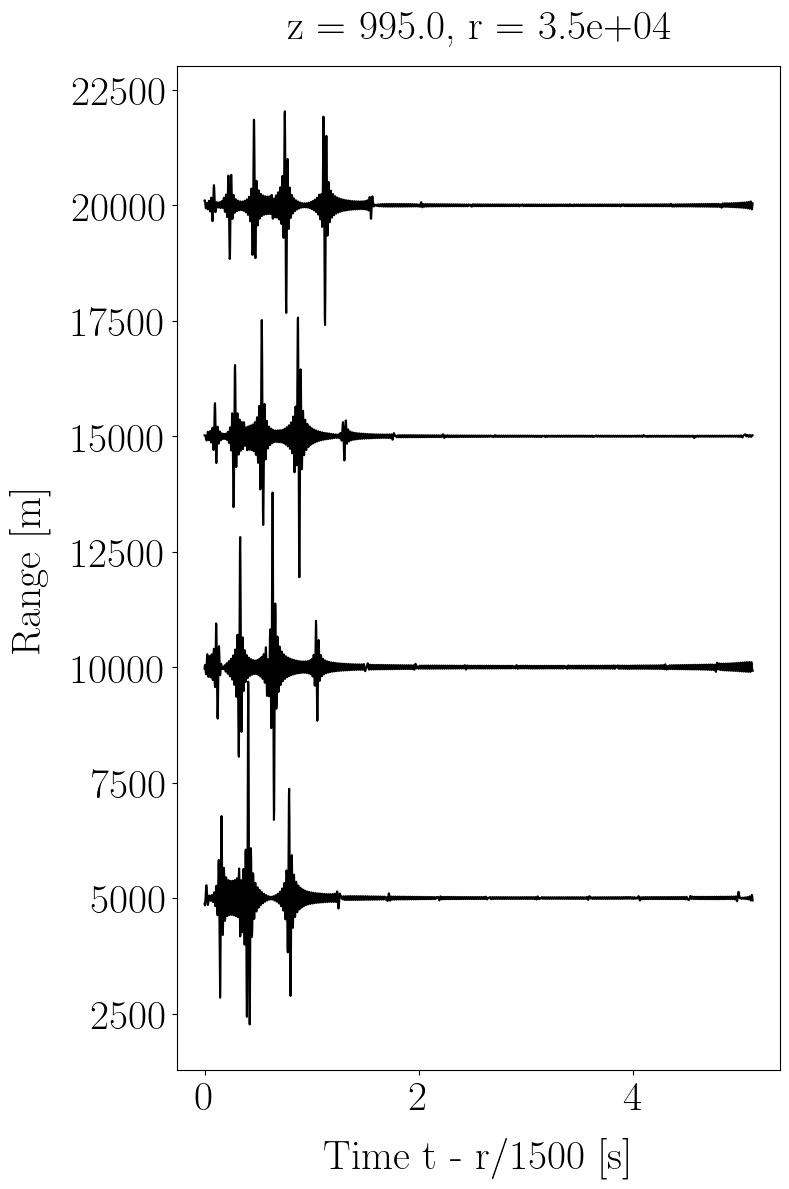

In [20]:
z_plot = 995

r_offset = r_visu_ir[1] - r_visu_ir[0]
ts = ds_ir.t.diff("t").values[0]
tau_roll = (
    r_visu_ir - ds_ir.r.min().values
) / g.c0  # Roll time axis to start at zero
idx_tau_roll = tau_roll / ts
idx_tau_roll = idx_tau_roll.astype(int)

# Scale for visualization
max_amplitude = ds_ir.s.max().values
alpha_dilatation = 1 * r_offset
ds_ir["s"] = ds_ir.s / max_amplitude * alpha_dilatation

# Loop over range to visualize impulse response
plt.figure(figsize=(8, 12))
for ir, r in enumerate(r_visu_ir):
    # Get ir at range r
    sig = ds_ir.s.sel(r=r, z=z_plot, method="nearest") + (ir + 1) * r_offset

    # Roll over time axis for current range
    sig_roll = sig.roll(t=-idx_tau_roll[ir], roll_coords=False)
    sig_roll.plot(color="k")

plt.xlabel(f"Time  t - r/{g.c0} [s]")
plt.ylabel("Range [m]")

Text(0, 0.5, 'Amplitude')

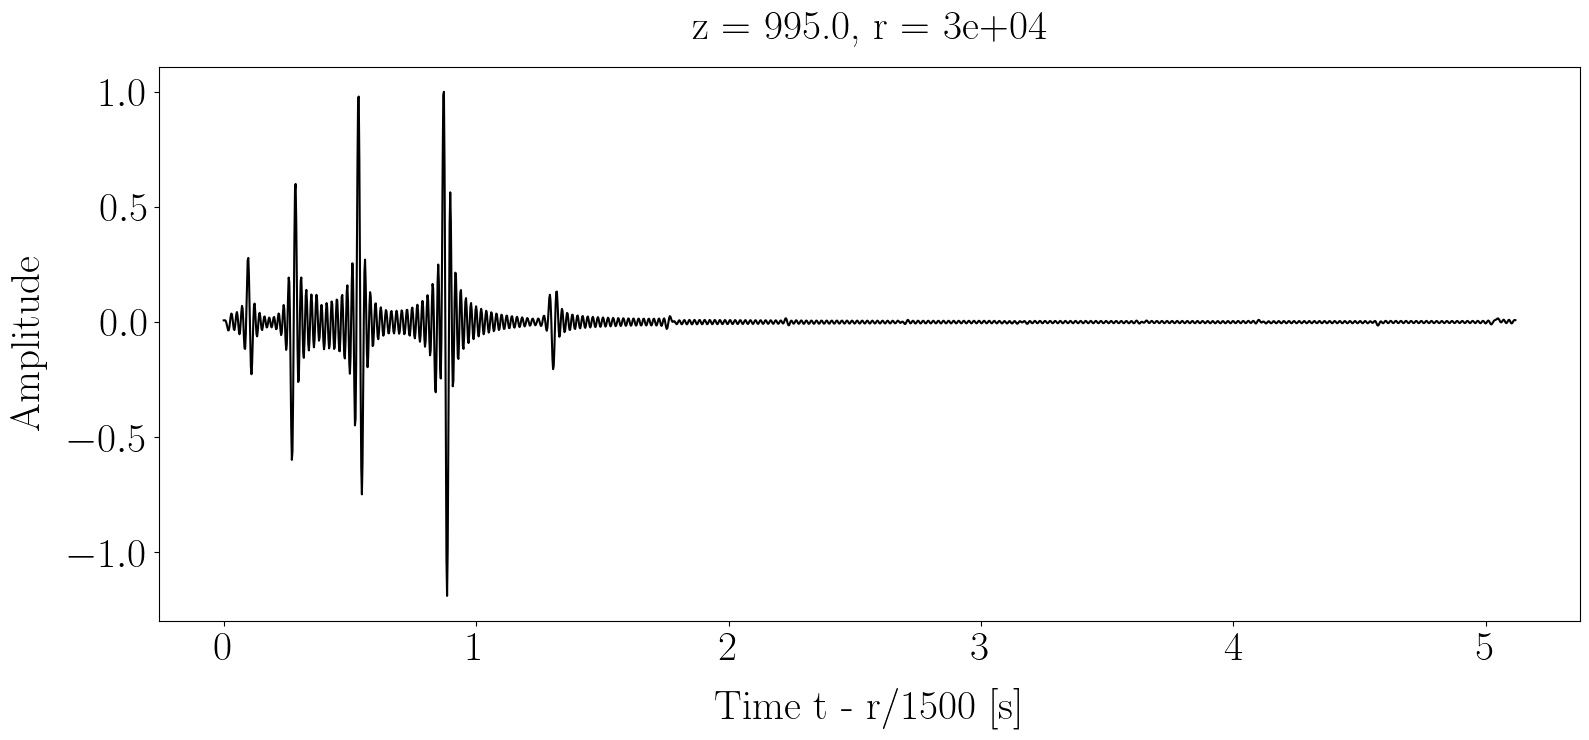

In [21]:
z_plot = 995
r_plot = 30*1e3

ts = ds_ir.t.diff("t").values[0]
tau_roll = (r_plot - ds_ir.r.min().values) / g.c0  # Roll time axis to start at zero
idx_tau_roll = tau_roll / ts
idx_tau_roll = idx_tau_roll.astype(int)

sig = ds_ir.s.sel(r=r_plot, z=z_plot, method="nearest")
sig = sig / sig.max().values
sig_roll = sig.roll(t=-idx_tau_roll, roll_coords=False)
sig_roll.plot(color="k")
plt.xlabel(f"Time  t - r/{g.c0} [s]")
plt.ylabel("Amplitude")

## Analogie avec la méthode source image 

In [22]:
arrivals = print_arrivals(z_src=src_depth, z_rcv=z_plot, r=r_plot, depth=depth, n=5)
# arrivals = arrivals[1:, :]

m = 1 : 
	 t1 = 20.099088978801447s 
	 t2 = 20.09975124224178s 
	 t3 = 20.09975124224178s 
	 t4 = 20.100415694982804s 

m = 2 : 
	 t1 = 20.27478017417479s 
	 t2 = 20.275875100994064s 
	 t3 = 20.275875100994064s 
	 t4 = 20.276972160556912s 

m = 3 : 
	 t1 = 20.535715229813643s 
	 t2 = 20.53722906766582s 
	 t3 = 20.53722906766582s 
	 t4 = 20.538744957870342s 

m = 4 : 
	 t1 = 20.878698341717676s 
	 t2 = 20.8806130178211s 
	 t3 = 20.8806130178211s 
	 t4 = 20.88252964667941s 

m = 5 : 
	 t1 = 21.299766300230722s 
	 t2 = 21.302060411560607s 
	 t3 = 21.302060411560607s 
	 t4 = 21.304356362021363s 



In [23]:
# Apply delay
tau_roll = (r_plot - ds_ir.r.min().values) / g.c0  # Roll time axis to start at zero
idx_tau_roll = tau_roll / ts
idx_tau_roll = idx_tau_roll.astype(int)

# Roll sig
sig = ds_ir.s.sel(r=r_plot, z=z_plot, method="nearest")
sig_roll = sig.roll(t=-idx_tau_roll, roll_coords=False)

# Delay arrivals
tau = r_plot / g.c0
delayed_arrivals = arrivals - tau
print(f"Delayed arrivals: {delayed_arrivals}")

Delayed arrivals: [[0.09908898 0.09975124 0.09975124 0.10041569]
 [0.27478017 0.2758751  0.2758751  0.27697216]
 [0.53571523 0.53722907 0.53722907 0.53874496]
 [0.87869834 0.88061302 0.88061302 0.88252965]
 [1.2997663  1.30206041 1.30206041 1.30435636]]


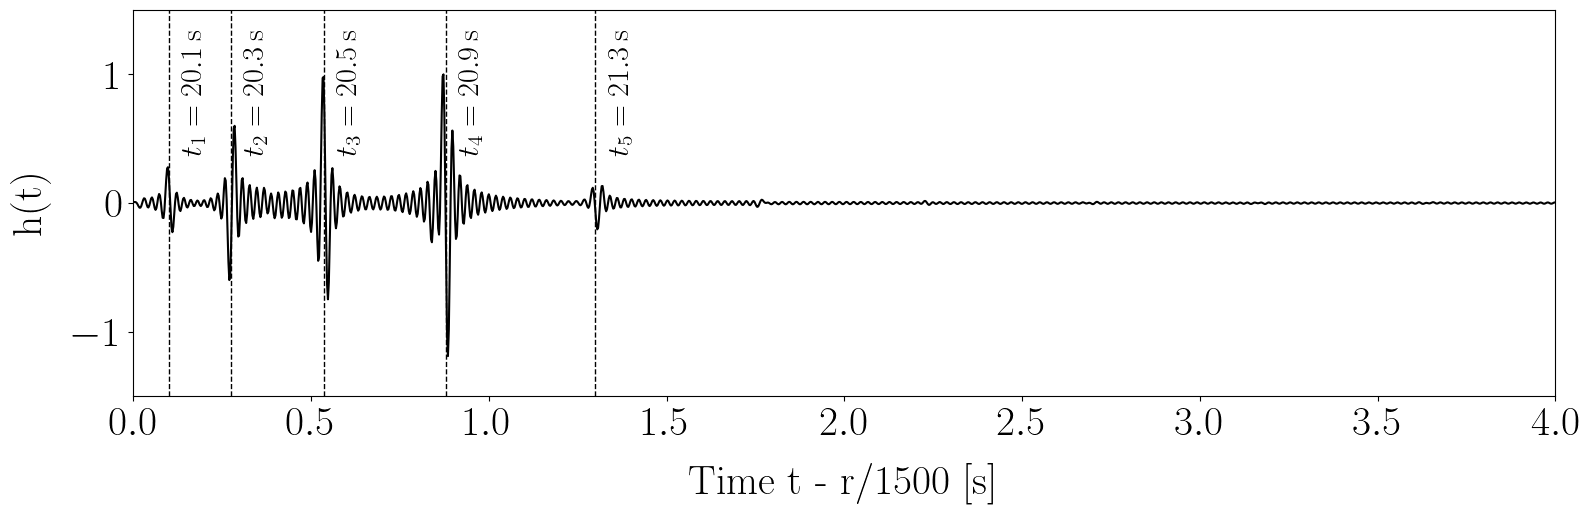

In [24]:
lf = LargeFigure()
plt.figure()
sig = ds_ir.s.sel(r=r_plot, z=z_plot, method="nearest")

# Normalize
max_amplitude = sig_roll.max().values
sig_roll = sig_roll / max_amplitude

sig_roll.plot(color="k")

for k in range(arrivals.shape[0]):
    plt.axvline(
        delayed_arrivals[k, 0],
        color="k",
        linestyle="--",
        linewidth=1,
    )
    plt.text(
        delayed_arrivals[k, 0] + 0.03,
        0.4,
        r"$t_{"
        + f"{k+1}"
        + r"} ="
        + f"{np.round(arrivals[k, 0], 1)}"
        + r"\, \textrm{s}$",
        rotation=90,
        color="k",
        fontsize=22,
    )

plt.xlabel(f"Time  t - r/{g.c0} [s]")
plt.ylabel("h(t)")
plt.ylim([-1.5, 1.5])
plt.xlim([0, 4])  # Cropp the end to avoid wrapped around signal artefacts 
# plt.legend()
plt.title("")
# Save figure as pdf
fpath = os.path.join(img_folder_path, f"{name}_ir_images_source_{r_plot:.0f}m.pdf")
plt.savefig(fpath)

## Durée de réverberation

$T_{60 \text{dB}}$ est défini comme le temps nécessaire pour que l'énergie acoustique décroisse de 60 dB 


Définition du SPL : 

$ SPL = 10 \log{ \frac{1}{p_0^2} \times \frac{1}{T} \int_0^{T} p(t)^2 dt}$

ou encore, 

$ SPL = 20 \log{ \frac{p_{rms}}{p_0} } $

avec, 

$p_{rms} \approx \sqrt{\frac{1}{K} \sum_{k=1}^{K} p[k]^2} $

Window duration for RMS: 0.25 s


(0.0, 4.0)

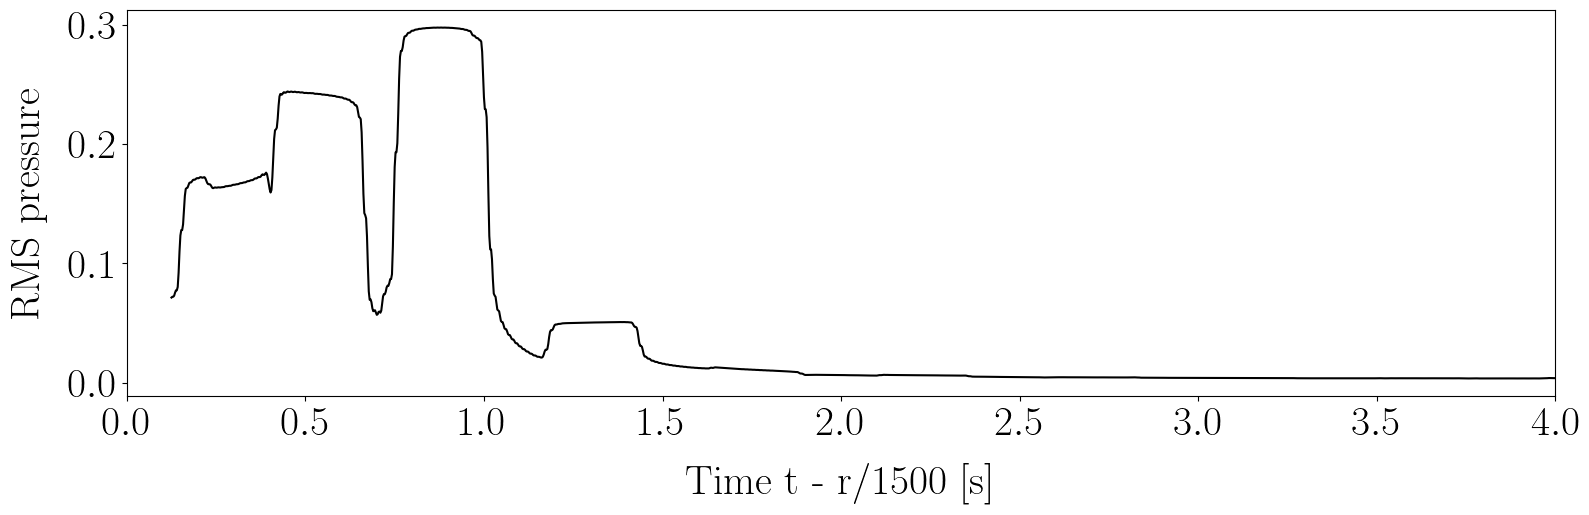

In [25]:
# Derive prms
p = sig_roll
t_win = 100
# print(f"Window size for RMS: {t_win} samples")
print(f"Window duration for RMS: {t_win * ts:.2f} s")
p2_roll = (p**2).rolling(t=t_win, center=True).mean()  
p_rms = np.sqrt(p2_roll)

# Plot p_rms
plt.figure()
p_rms.plot(color="k")
plt.xlabel(f"Time  t - r/{g.c0} [s]")
plt.ylabel("RMS pressure")
plt.title("")
plt.xlim([0, 4])  # Cropp the end to avoid wrapped around signal artefacts

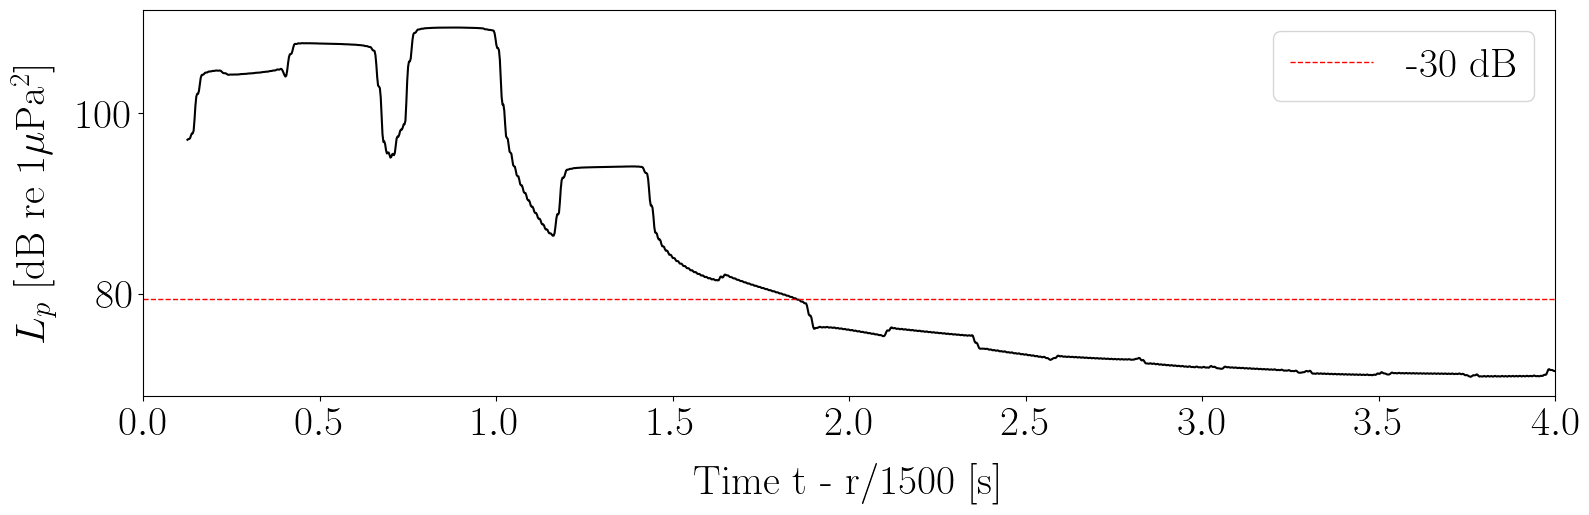

In [26]:
# Derive SPL
# p_rms /= p_rms.max().values
spl = 20 * np.log10(p_rms / g.p0)

# Plot spl
spl.plot(color="k")

# Add threshold line
threshold = -30  # Threshold in dB
th = np.max(spl).values + threshold
plt.axhline(
    y=th,
    color="r",
    linestyle="--",
    linewidth=1,
    label=f"{threshold} dB",
)


plt.xlim([0, 4])  # Cropp the end to avoid wrapped around signal artefacts
plt.xlabel(f"Time  t - r/{g.c0} [s]")
plt.ylabel(r"$L_p$ [dB re 1$\mu$Pa$^2$]")
plt.legend()
plt.title("")

# Save figure as pdf
fpath = os.path.join(img_folder_path, f"{name}_ir_Lp_{r_plot:.0f}m.pdf")
plt.savefig(fpath)

In [27]:
# Derive tau_th 
tau_th = spl.t.where(spl < th).dropna("t").values[0]
print(f"Reverberation time ({threshold} dB) : {tau_th:.2f} s")

Reverberation time (-30 dB) : 1.85 s


# Génération du jeux de données pour l'estimation des performances des méthodes de RTF 

## Paramètres de la source 

In [8]:
output_fs = 4 * src_fs  # Output sampling frequency after propagation

# Number of snapshot desired to derive cov matrix
n_cov_snapshots = 10
# Cov snapshot lenght
cov_snapshot_duration = np.round(tau_th, 0)
cov_snapshot_size = int(
    cov_snapshot_duration * output_fs
)  # Number of samples in the time window to compute the covariance matrix
cov_snapshot_final_size = 2 ** int(np.log2(cov_snapshot_size) + 1)  # Next power of 2
effective_cov_snapshot_duration = cov_snapshot_final_size / output_fs

# Derive signal duration
src_signal_duration = effective_cov_snapshot_duration * n_cov_snapshots

print(f"Number of snapshots to derive cov matrix: {n_cov_snapshots}")
print(f"Cov snapshot duration: {effective_cov_snapshot_duration} s")
print(f"Source signal duration: {src_signal_duration} s")

Number of snapshots to derive cov matrix: 10
Cov snapshot duration: 2 s
Source signal duration: 25.6 s


In [29]:
src_depth = depth - 1 # Reciprocity -> receiver depth 
src_min_freq = 0 # Hz
src_max_freq = 50 # Hz
src_fs = 100  # Hz

# Create dummy signal to make it easy to run kraken simulation
fc = 25
sg = SignalGenerator()
s, t = sg.pulse(T=src_signal_duration, fc=fc, fs=src_fs, t0=0)
s = sg.normalize_sig(s, normalize="max")

src = AcousticSource(
    signal=s,
    time=t,
    name="Pulse",
    waveguide_depth=depth,
    window=None,
    nfft=2 ** int(np.log2(s.size) + 1),
)

## Paramètres du domaine de calcul 

In [30]:
max_range_km = 45
min_range_km = 15

## Définition du cas test avant calcul Kraken

In [31]:
name = "perekis_short_ir_waveguide_perf"
title = "Pekeris waveguide with short impulse response - for RTF methods performance study"

# Common properties
zmin = 0
zmax = depth
rmax = max_range_km * 1e3
rmin = min_range_km * 1e3

min_phase_speed = 1000
max_phase_speed = 20000

bott_props = {
    "rho": rho_sediment * 1e-3,  # Density (g/cm^3)
    "c_p": c_sediment,  # P-wave celerity (m/s)
    "c_s": 0.0,  # S-wave celerity (m/s)
    "a_p": alpha_sediment,  # Compression wave attenuation (dB/wavelength)
    "a_s": 0.0,  # Shear wave attenuation (dB/wavelength)
}

# Set domain properties
domain_properties = DomainProperties(zmin=zmin, zmax=zmax, rmin=rmin, rmax=rmax, unit="m")

# Set source properties
src_properties = SourceProperties(
    src_type="point_source", src_depth=src_depth, freq=src.kraken_freq
)
# Set receiver properties : needs to cover the whole water domain
rcv_z_min = zmin
rcv_z_max = depth

# Number of receiver depths / ranges (flp file) : sufficient resolution for later use (can be easily downsampled afterwards)
dr = 50
dz = 5
nr_flp = int((rmax - rmin) / dr) + 1
nz_flp = int(rcv_z_max / dz) + 1

rcv_properties = ReceiverProperties(
    zmin=rcv_z_min, zmax=rcv_z_max, rmin=rmin, rmax=rmax, unit="m"
)

# Set kraken properties
nmedia = 2

top_hs = KrakenTopHalfspace(
    boundary_condition="vacuum",
    halfspace_properties=None,
    twersky_scatter_properties=None,
)

bott_hs = KrakenBottomHalfspace(
    boundary_condition="acousto_elastic",
    sigma=0.0,
    halfspace_properties=bott_props,
    fmin=src.kraken_freq.min(),
    alpha_wavelength=10,
)
# Set attenuation properties
att = KrakenAttenuation(units="dB_per_wavelength", use_volume_attenuation=False)
# Set SSP profile
z = [0, zmax]
c = [c_water, c_water]  # Constant celerity profile
ssp = SSPProfile(z=z, c=c)

# Create the medium = water column layer
medium = KrakenMedium(
    ssp_interpolation_method="C_linear",
    z_ssp=ssp.z,
    c_p=ssp.c,
    c_s=0.0,
    rho=1.0,
    a_p=0.0,
    a_s=0.0,
    nmesh=0,
    sigma=0.0,
)

bott_hs.derive_sedim_layer_max_depth(domain_properties.zmax_m)
max_rcv_depth = bott_hs.sedim_layer_max_depth
n_rcv_z = default_nb_rcv_z(
    fmax=src.kraken_freq.max(), max_depth=max_rcv_depth, n_per_l=10
)
field = KrakenField(
    phase_speed_limits=[min_phase_speed, max_phase_speed],
    src_depth=[src_properties.depth],
    n_rcv_z=n_rcv_z,
    rcv_z_min=0,
    rcv_z_max=max_rcv_depth,
    rcv_r_max=0.0,
)

kraken_properties = KrakenProperties(
    mode_coupling="coupled",
    mode_addition="coherent",
    n_mode=100,
    nr=nr_flp,
    nz=nz_flp,
    nmedia=nmedia,
    top_hs=top_hs,
    bott_hs=bott_hs,
    att=att,
    medium=medium,
    field=field,
)


k_tc = KrakenTestCase(
    name=name,
    title=title,
    root_dir=tc_root_dir,
    domain_properties=domain_properties,
    src_properties=src_properties,
    rcv_properties=rcv_properties,
    kraken_properties=kraken_properties,
)

In [32]:
# Kraken compute otpion
# run_kraken = False
run_kraken = True

In [33]:
if run_kraken:
    km = KrakenManager()

    # Because of the large number of frequencies we need to split the calculation into frequency chunks -> field does not work with broadband simulation using
    # nf > 1000 frequencies
    all_freqs = k_tc.src.freq
    chunk_size = 950  # Number of frequencies per chunk
    n_chunks = int(np.ceil(len(all_freqs) / chunk_size))
    pressure_field = []
    for ichunk in range(n_chunks):
        # Get the frequencies for the current chunk
        start_freq = ichunk * chunk_size
        end_freq = min((ichunk + 1) * chunk_size, len(all_freqs))
        freq_chunk = all_freqs[start_freq:end_freq]

        # Run Kraken for the current chunk
        print(f"Running Kraken for frequencies {start_freq} to {end_freq - 1} (chunk {ichunk + 1}/{n_chunks})")

        # update env freq 
        k_tc.env.freq = freq_chunk
        # Run Kraken and get the pressure field
        p, field_pos = km.runkraken(
            env=k_tc.env, flp=k_tc.flp, frequencies=freq_chunk
        )

        # Append the pressure field for the current chunk
        pressure_field.append(p)


    # Concatenate the pressure fields from all chunks
    pressure_field = np.concatenate(pressure_field, axis=0)


    # pressure_field, field_pos = km.runkraken(
    #     env=k_tc.env, flp=k_tc.flp, frequencies=k_tc.src.freq
    # )

Running Kraken for frequencies 0 to 949 (chunk 1/2)
Running Kraken for frequencies 950 to 1016 (chunk 2/2)


In [34]:
if run_kraken:
    # Store pressure field as netcdf using xarray
    pressure_field = np.squeeze(pressure_field)  # Remove singleton dimensions if any
    ds_tf = xr.Dataset(
        data_vars=dict(
            tf_real=(["f", "z", "r"], np.real(pressure_field)),
            tf_imag=(["f", "z", "r"], np.imag(pressure_field)),
        ),
        coords=dict(
            f=k_tc.src.freq,
            z=field_pos["r"]["z"],
            r=field_pos["r"]["r"],
        ),
        attrs=dict(
            title="Transfer functions for Pekeris waveguide",
            description="Transfer functions computed using Kraken for a Pekeris waveguide with short impulse response.",
            # date_created=np.datetime64("now"),
            note="Dataset for rtf performance analysis purpose: lower spatial resolution, reduced range coverage and long signal duration.",
            type="perf",
            fs=src_fs,
            signal_duration=src_signal_duration,
            waveguide_depth=depth,
            src_depth=src_depth,

        ),
    )
    # Save to netcdf
    tf_perf_fpath = os.path.join(data_folder_path, "tf_perf.nc")
    ds_tf.to_netcdf(tf_perf_fpath)
else:
    # Load transfer functions from netcdf
    ds_tf = xr.open_dataset(tf_perf_fpath)